<a href="https://colab.research.google.com/github/Divya4325/EcoType-Forest-Cover-Classification/blob/main/EcoType_Forest_Cover_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) **Data Collection**


In [1]:
!pip install scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 73.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
path='/content/drive/MyDrive/Forest_Cover.csv'
df=pd.read_csv(path)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


# 2) **Data Understanding**

*Shape of the dataset*

In [9]:
df.shape    # Shape of the dataset

(145890, 13)

*Info for each columns*

In [8]:
df.info()  # information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [7]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

*Describe the each columns*

In [6]:
df.describe()  #Description of the dataset

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


*Value_Counts for all columns*

In [5]:
for col in df[['Cover_Type','Wilderness_Area','Soil_Type']]:   #Categorical Columns
 print(f"{df[col].value_counts()}\n")

Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

Wilderness_Area
1    134367
3      6349
4      4675
2       499
Name: count, dtype: int64

Soil_Type
29    60696
12    29144
30    18158
23    10150
20     6098
16     2219
24     2169
10     2142
18     1829
39     1210
9      1112
19     1046
3       962
22      931
4       843
38      803
40      736
32      690
6       650
2       623
33      616
17      612
13      476
11      406
1       356
31      332
8       179
14      169
5       165
7       105
35      102
26       54
37       34
34       22
21       16
27       15
36       10
28        9
25        1
Name: count, dtype: int64



In [10]:
for col in df[['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',   #continuous Columns
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']]:
   print(f"{df[col].value_counts()}\n")

Elevation
2972    1046
2968    1037
2991    1023
2978    1015
2975    1006
        ... 
3591       1
3604       1
2012       1
1978       1
2017       1
Name: count, Length: 1665, dtype: int64

Aspect
45     2627
90     1728
135    1660
0      1596
63     1087
       ... 
271      90
227      78
224      46
226      37
360       6
Name: count, Length: 361, dtype: int64

Slope
10    10827
9     10173
8      9783
11     9781
12     9630
7      8784
13     8682
6      8000
14     7759
15     7013
5      6831
16     6003
4      5537
17     4746
18     4194
3      3696
19     3325
20     2792
2      2581
21     2246
22     2023
23     1730
24     1504
1      1401
25     1263
26     1083
27      874
28      730
29      568
30      424
31      392
32      312
0       244
33      229
34      199
35      148
36       99
37       86
38       50
39       42
41       22
40       21
46       18
42        6
49        5
45        5
44        5
47        4
61        3
52        3
43        3
57       

*Checking Duplicates for the dataset*

In [11]:
df.duplicated().sum()   #There is no duplicates in the dataset

np.int64(0)

*Checking Missing values for the dataset*

In [12]:
df.isnull().sum()    # There is no null values in the dataset

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


*class distribution imbalance*

In [13]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


## *Here This Dataset is Strongly imbalanced with one data called Lodgepole Pine which has 70%*

In [14]:
df['Cover_Type'].value_counts(normalize=True)*100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


# 3). **Data Cleaning and Transformation**

*Handle missing values by imputing with appropriate techniques(like median,mean,mode)*


**Missing value analysis was performed using isnull().sum(). It was observed that there are no missing values in the dataset. Therefore, no imputation techniques were required.**

**Detecting Outliers **

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


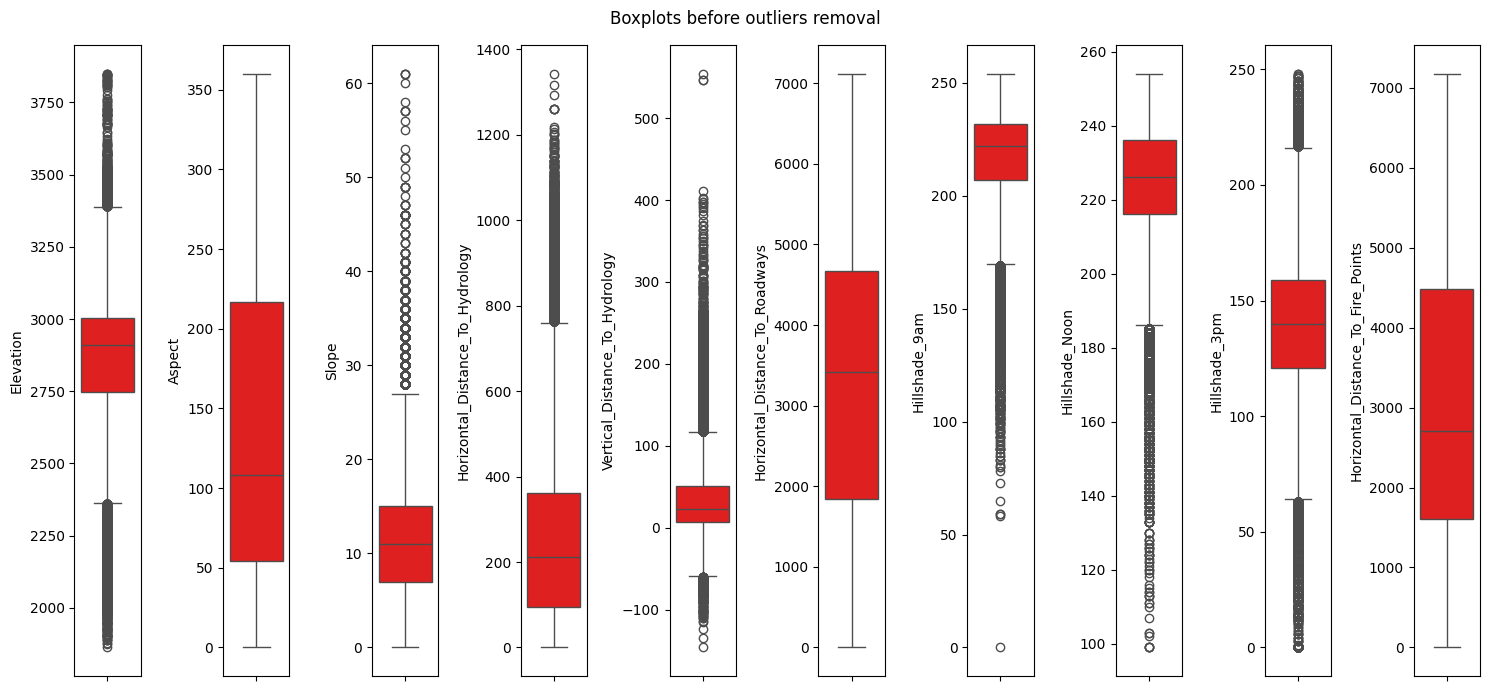

In [16]:
numerical_cols=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',   #continuous Columns
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']



plt.figure(figsize=(15,7))
plt.suptitle("Boxplots before outliers removal")
for i in range(0,len(numerical_cols)):
  plt.subplot(1,10,i+1)
  sns.boxplot (y=df[numerical_cols[i]],color='red')
  plt.tight_layout()

In [ ]:
len(df)

145890

In [ ]:
(25/100)*(145890+1)

36472.75

In [ ]:
df['Elevation'].quantile(0.25)

np.float64(2747.0)

In [ ]:
df['Elevation'].sort_values().reset_index().iloc[36473]

,36473
index,142055
Elevation,2747


In [ ]:
(75/100)*(145890+1)

109418.25

In [ ]:
df['Elevation'].quantile(0.75)

np.float64(3004.0)

In [ ]:
df['Elevation'].sort_values().reset_index().iloc[109418]

,109418
index,67247
Elevation,3004


In [ ]:
from numpy._core.defchararray import lower
q1=2747
q3=3004
iqr=257
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print(lower,upper)

2361.5 3389.5


In [17]:
numerical_cols=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',   #continuous Columns
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']
skewness=df[numerical_cols].skew()
skewness

,0
Elevation,-0.664497
Aspect,0.689432
Slope,0.943937
Horizontal_Distance_To_Hydrology,0.984953
Vertical_Distance_To_Hydrology,1.792939
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-1.286839
Hillshade_Noon,-0.945446
Hillshade_3pm,-0.165213
Horizontal_Distance_To_Fire_Points,0.365249


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


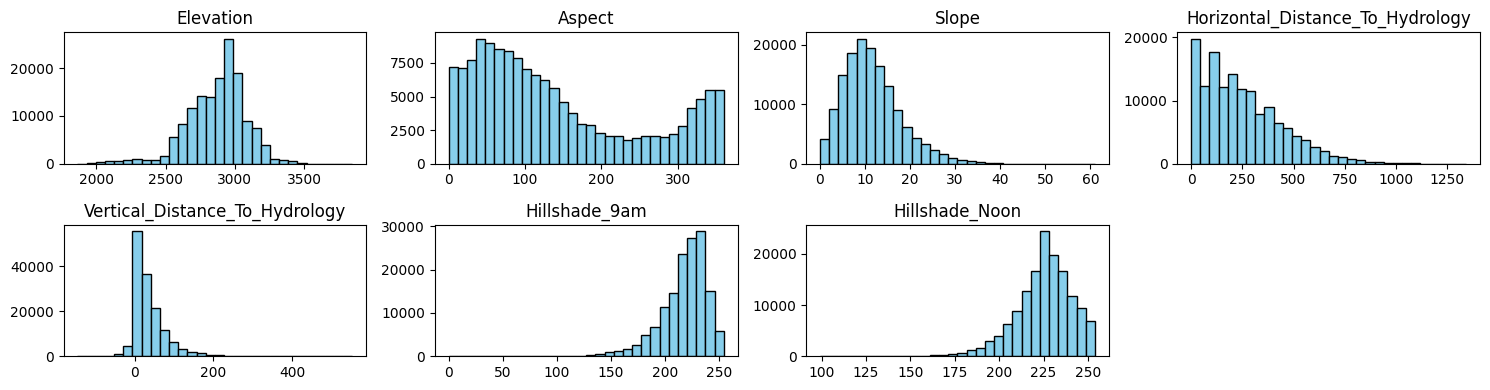

In [19]:
skewed_cols = skewness[abs(skewness) > 0.5].index
plt.figure(figsize=(15, 4))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(2, 4, i)  # Adjust grid size as needed
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

Horizontal_Distance_To_Roadways
Hillshade_3pm →
Horizontal_Distance_To_Fire_Points

**These columns does not require skewness because there values between -0.5 To 0.5**




Aspect,
Slope,
Horizontal_Distance_To_Hydrology,
Vertical_Distance_To_Hydrology,
Hillshade_9am,Elevation,Hillsade_Noon

### **These columns need to handle skewness because there values exceed beyond -0.5 To 0.5 **

# 4). **Feature Engineering**

**So Now Going to create new columns derived from exisitng columns which help us to improve model performance**

*A. Distance Ratios*

In [20]:
df['Hydrology']=(df['Horizontal_Distance_To_Hydrology']/df['Vertical_Distance_To_Hydrology']+1)

In [21]:
df['Elevation_Hydrology']=df['Elevation']*df['Horizontal_Distance_To_Hydrology']

In [22]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Hydrology,Elevation_Hydrology
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29,inf,669768
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29,-34.333333,549080
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12,5.123077,751472
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30,3.050847,673970
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29,-152.000000,397035


*I am doing Visualization first beforing doing encoding*

# 5). **Exploratory Data Analysis (EDA)**

**Univariate Analysis**

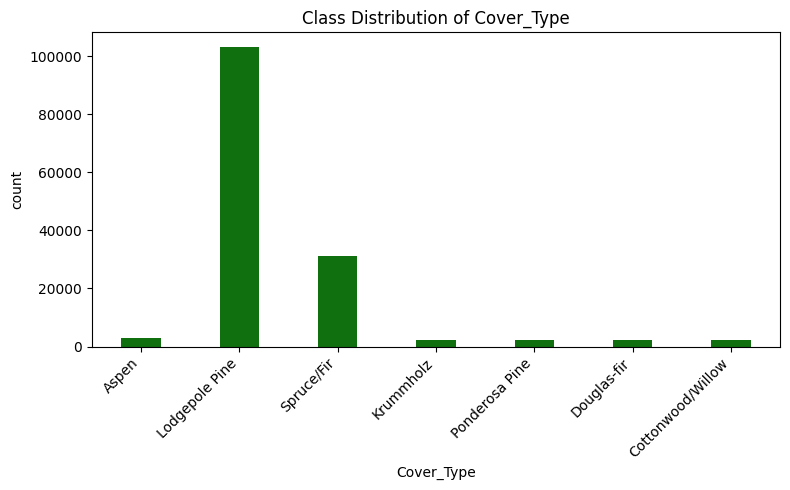

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type',data=df,color='green',width=0.4)
plt.title("Class Distribution of Cover_Type")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

**Bivariate analysis**

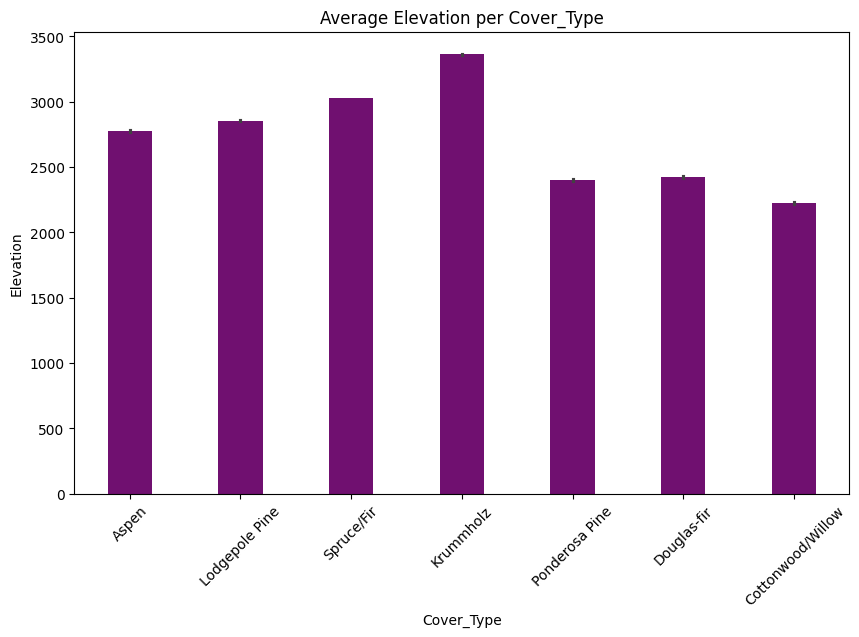

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x='Cover_Type',y='Elevation',data=df,estimator='mean',color='purple',width=0.4)
plt.xticks(rotation=45)
plt.title("Average Elevation per Cover_Type")
plt.show()


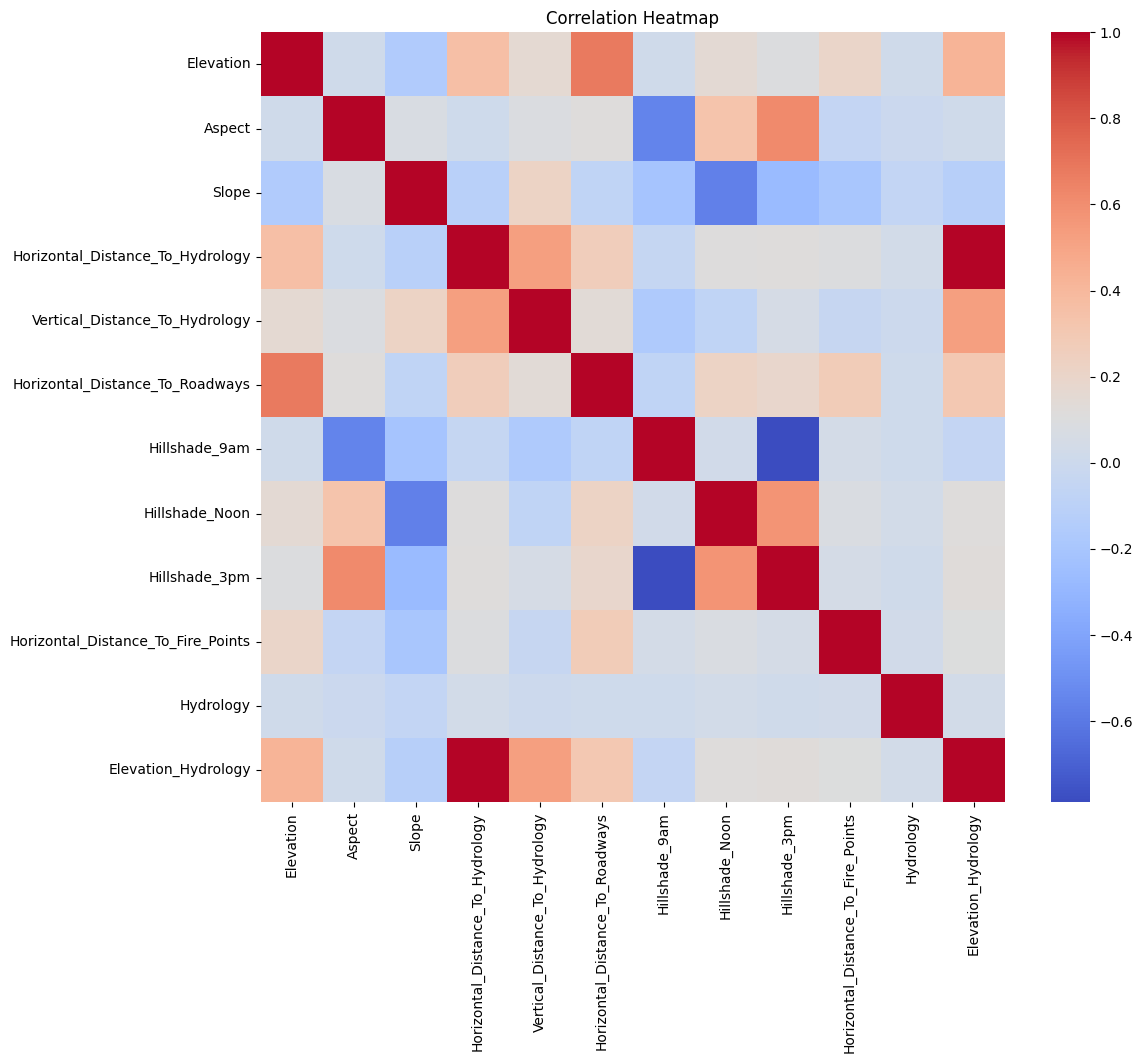

In [25]:
num_columns=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Hydrology', 'Elevation_Hydrology']
plt.figure(figsize=(12,10))
sns.heatmap(df[num_columns].corr(),cmap='coolwarm',annot=False)
plt.title("Correlation Heatmap")
plt.show()

**Encoding for Cover_Type which comes under Feature Engineering**


**But target_column not encoded that's why using LabelEncoder**


**Split the data also done here itself**

In [26]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

le = LabelEncoder()
y = le.fit_transform(y)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [27]:
print(np.unique(y_train))

[0 1 2 3 4 5 6]


In [28]:
import joblib
joblib.dump(le,'/content/drive/MyDrive/target_encoder.pkl')

['/content/drive/MyDrive/target_encoder.pkl']

**Columns like:**

*Soil_Type*,
Wilderness_Area
**Doing one-hot encoder

In [29]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_cols = ['Wilderness_Area', 'Soil_Type']

# ✅ Fit only on TRAIN
X_train_cat = ohe.fit_transform(X_train[cat_cols])

# ✅ Only transform TEST
X_test_cat = ohe.transform(X_test[cat_cols])

# Numeric part
X_train_num = X_train.drop(columns=cat_cols).values
X_test_num = X_test.drop(columns=cat_cols).values

# Combine
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

In [30]:
import joblib
joblib.dump(ohe,'/content/drive/MyDrive/onehot_encoder.pkl')

['/content/drive/MyDrive/onehot_encoder.pkl']

*Outlier Handling (Train only)*

In [31]:
numerical_columns = X_train.select_dtypes(include='int64')

In [32]:

for col in numerical_cols:
  Q1=X_train[col].quantile(0.25)
  Q3=X_train[col].quantile(0.75)
  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  X_train[col]=X_train[col].clip(lower,upper)
  X_test[col]=X_train[col].clip(lower,upper)

**After Handling Outliers **

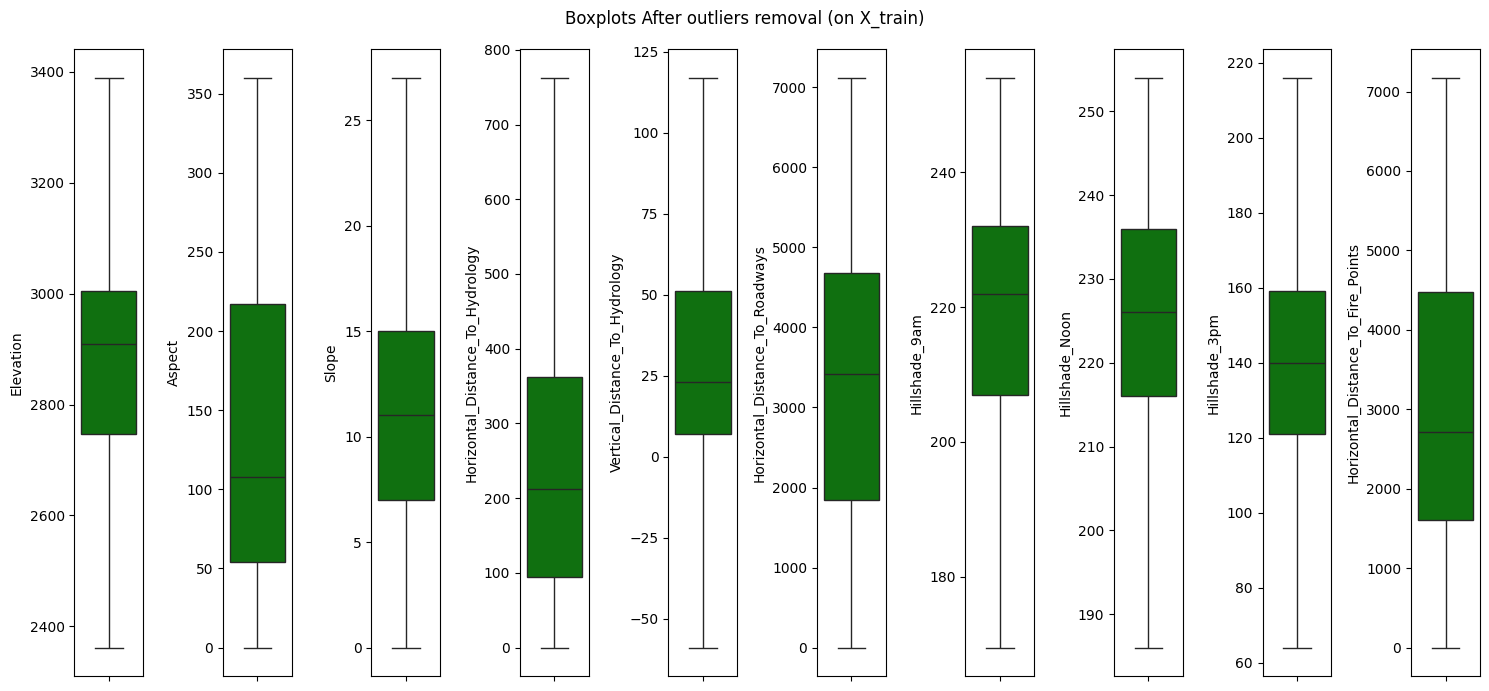

In [33]:
plt.figure(figsize=(15,7))
plt.suptitle("Boxplots After outliers removal (on X_train)")
for i in range(0,len(numerical_cols)):
  plt.subplot(1,len(numerical_cols),i+1)
  sns.boxplot (y=X_train[numerical_cols[i]],color='green') # Changed df to X_train
  plt.tight_layout()

**Skewness Handling(Only Train)**

In [34]:
skew_cols=['Aspect','Slope',
'Horizontal_Distance_To_Hydrology',
'Vertical_Distance_To_Hydrology',
'Hillshade_9am','Elevation','Hillshade_Noon']

In [35]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

# Fit on train
X_train[skew_cols] = pt.fit_transform(X_train[skew_cols])

# Transform test
X_test[skew_cols] = pt.transform(X_test[skew_cols])



In [36]:
print(X_train[skew_cols].skew())

Aspect                             -0.100515
Slope                              -0.020545
Horizontal_Distance_To_Hydrology   -0.168553
Vertical_Distance_To_Hydrology      0.088175
Hillshade_9am                      -0.097625
Elevation                          -0.000337
Hillshade_Noon                     -0.040826
dtype: float64


# **Feature Selection**


In [37]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [38]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)

feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)

top_features = feat_imp.sort_values(ascending=False).head(15).index

In [39]:
X_train = X_train[top_features].copy()
X_test = X_test[top_features].copy()

***Bar Graph for Feature Importance***

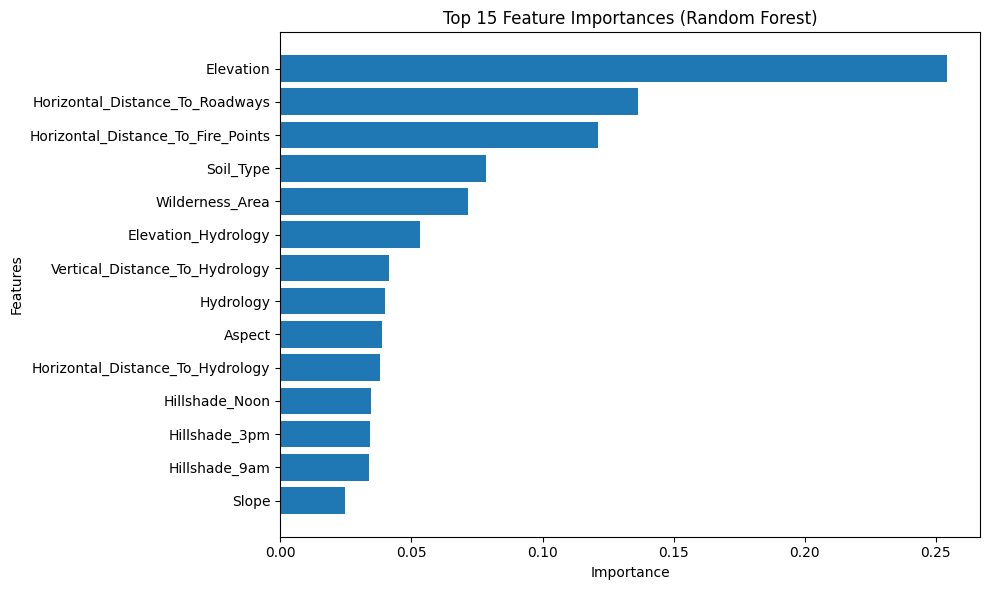

In [40]:
top15 = feat_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10,6))
plt.barh(top15.index, top15.values)

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [41]:
top_features_list=list(top_features)  #Columns to consider for the model
top_features_list

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Soil_Type',
 'Wilderness_Area',
 'Elevation_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Hydrology',
 'Aspect',
 'Horizontal_Distance_To_Hydrology',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Hillshade_9am',
 'Slope']

Scaling


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Replace inf/-inf with NaN first
X_train_final = np.where(np.isinf(X_train_final), np.nan, X_train_final)
X_test_final = np.where(np.isinf(X_test_final), np.nan, X_test_final)

# Impute NaN values (including those converted from inf) using SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_final = imputer.fit_transform(X_train_final)
X_test_final = imputer.transform(X_test_final)

scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)


In [65]:
import joblib
joblib.dump(scaler,'/content/drive/MyDrive/scale.pkl')

['/content/drive/MyDrive/scale.pkl']

In [44]:
import joblib
joblib.dump(imputer,'/content/drive/MyDrive/imputer.pkl')

['/content/drive/MyDrive/imputer.pkl']

***Class Imbalance***

In [45]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        0: 5000,
        1: 5000,
        2: 5000,
        3: 5000,
        5: 5000
    },
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train_final, y_train)


In [49]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy={4: 15000, 6: 15000},  # reduce a bit
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(X_train_res, y_train_res)


In [47]:
import pandas as pd
print(pd.Series(y_train_res).value_counts())

4    15000
6    15000
0     5000
2     5000
1     5000
3     5000
5     5000
Name: count, dtype: int64


# **Model Building**


**Logistic Regression**

In [53]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    solver='lbfgs', # Changed solver to 'lbfgs'
    class_weight='balanced'
)

lr.fit(X_train_res, y_train_res)

# Predict on scaled test data
lr_pred = lr.predict(X_test_final)

**KNeighborsClassifier**

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
# Train on smode data
knn.fit(X_train_res, y_train_res)

# Predict on test data(No Scaling)
knn_pred = knn.predict(X_test_final)


**RandomForestClassifier**

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced'
)

rf.fit(X_train_res, y_train_res)
rf_pred = rf.predict(X_test_final)

** DecisionTreeClassifier**

In [56]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=20
)

dt.fit(X_train_res, y_train_res)
dt_pred = dt.predict(X_test_final)

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    objective='multi:softprob',
    num_class=7,
    eval_metric='mlogloss'

)

xgb.fit(X_train_res, y_train_res)
xgb_pred = xgb.predict(X_test_final)

In [58]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

import numpy as np

def evaluate(name, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))
    print("F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))
    print(classification_report(y_test, y_pred, zero_division=0))

evaluate("Logistic Regression", lr_pred)
evaluate("KNN", knn_pred)
evaluate("Random Forest", rf_pred)
evaluate("Decision Tree", dt_pred)
evaluate("XGBoost", xgb_pred)


===== Logistic Regression =====
Accuracy: 0.662622523819316
[[  475     0    21     0    72    13    33]
 [    0   370    26     0     0    36     0]
 [    9    38   281     0     0   104     0]
 [    1     0     0   417     0     3    11]
 [ 2945     0    14    21 13339     7  4288]
 [   15    50    95     0     0   272     0]
 [  285     0     9   133  1615     0  4180]]
F1 (macro): 0.6378766870466254
F1 (weighted): 0.6978207125463434
              precision    recall  f1-score   support

           0       0.13      0.77      0.22       614
           1       0.81      0.86      0.83       432
           2       0.63      0.65      0.64       432
           3       0.73      0.97      0.83       432
           4       0.89      0.65      0.75     20614
           5       0.63      0.63      0.63       432
           6       0.49      0.67      0.57      6222

    accuracy                           0.66     29178
   macro avg       0.61      0.74      0.64     29178
weighted avg    

In [59]:
from sklearn.model_selection import cross_val_score
import numpy as np

models={
    "Logistic Regression":lr,
    "KNN":knn,
    "Random Forest":rf,
    "Decision Tree":dt,
    "XGBoost":xgb
}
results={}
for name,model in models.items():
    scores=cross_val_score(
        model, # Added the 'model' estimator here
        X_train_res,
        y_train_res,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    results[name] = {
        "Mean F1": np.mean(scores),
        "Std": np.std(scores)
    }

# Print results
for model_name, metrics in results.items():
    print(f"{model_name}: Mean F1 = {metrics['Mean F1']:.4f}, Std = {metrics['Std']:.4f}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Logistic Regression: Mean F1 = 0.7283, Std = 0.0023
KNN: Mean F1 = 0.9052, Std = 0.0094
Random Forest: Mean F1 = 0.9428, Std = 0.0073
Decision Tree: Mean F1 = 0.9188, Std = 0.0077
XGBoost: Mean F1 = 0.9339, Std = 0.0047


In [60]:
import joblib
joblib.dump(rf,'/content/drive/MyDrive/rf_model.pkl')

['/content/drive/MyDrive/rf_model.pkl']

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [62]:

rf=RandomForestClassifier(random_state=42)
rf_params={
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt'],
    'bootstrap':[True]
}
rf_random=RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
rf_random.fit(X_train_res,y_train_res)
print("Best Params of RandomForest:",rf_random.best_params_)
print("Best Score of RandomForest:",rf_random.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params of RandomForest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
Best Score of RandomForest: 0.9412252266042631


In [63]:
best_model = rf_random.best_estimator_

In [64]:
import joblib
joblib.dump(best_model,'/content/drive/MyDrive/rf_final.pkl')

['/content/drive/MyDrive/rf_final.pkl']